**Sub questions:**
- **(a)** Show mathematically that the first-order partial derivatives of $G(x,y)$:
- **(b)** Using NumPy, compute **normalized 5×5 DoG kernels** for σ = 2 (x and y directions)
- **(c)** Visualize a **51×51 DoG kernel** (x-direction) as a **3D surface plot**
- **(d)** Apply the DoG kernels to a grayscale image to get **horizontal and vertical gradients**
- **(e)** Compute gradients using **`cv.Sobel()`** and **compare** with DoG results

**Image:** `einstein.png`

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import os

img = cv.imread('../images/a1images/einstein.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "Could not load einstein.png"

print(f"Image : einstein.png")
print(f"Shape : {img.shape}")
print(f"Dtype : {img.dtype}")
print(f"Mean  : {img.mean():.2f} | Std: {img.std():.2f}")

os.makedirs('../outputs/q6', exist_ok=True)


Image : einstein.png
Shape : (380, 364)
Dtype : uint8
Mean  : 125.91 | Std: 83.72


## (a) Mathematical Derivation of First-Order Partial Derivatives

### Physical Interpretation

- $\partial G/\partial x$ is an **odd function in x** (antisymmetric) — it detects
  **vertical edges** (intensity changes in the horizontal direction)
- $\partial G/\partial y$ is an **odd function in y** (antisymmetric) — it detects
  **horizontal edges** (intensity changes in the vertical direction)
- Both kernels sum to **zero** because they are antisymmetric — a uniform region
  produces zero response
- The Gaussian component provides **built-in smoothing** before differentiation,
  making DoG more **noise-robust** than pure finite-difference gradients


## (b) Normalized 5×5 DoG Kernels, σ = 2

In [21]:
def dog_kernels(size, sigma):
    """
    Compute normalized 2D Derivative-of-Gaussian kernels.

    Uses the analytical formulae:
        dG/dx = -(x / sigma^2) * G(x, y)
        dG/dy = -(y / sigma^2) * G(x, y)

    Normalization: divide by the sum of absolute values so that
    the response to a unit step edge equals 1.

    Parameters:
        size  : int   — kernel size (must be odd)
        sigma : float — Gaussian standard deviation

    Returns:
        kernel_dx : np.ndarray — x-direction DoG kernel
        kernel_dy : np.ndarray — y-direction DoG kernel
    """
    assert size % 2 == 1, "Kernel size must be odd"

    half = size // 2
    ax   = np.arange(-half, half + 1)        # e.g. [-2,-1,0,1,2]
    X, Y = np.meshgrid(ax, ax)               # 2D coordinate grids

    # Step 1: compute base Gaussian (without 1/(2pi*sigma^2) prefactor)
    G = np.exp(-(X**2 + Y**2) / (2.0 * sigma**2))

    # Step 2: apply the derivative formulae
    dG_dx = -(X / sigma**2) * G             # dG/dx = -(x/sigma^2) * G
    dG_dy = -(Y / sigma**2) * G             # dG/dy = -(y/sigma^2) * G

    # Step 3: normalize by sum of absolute values
    dG_dx_norm = dG_dx / np.abs(dG_dx).sum()
    dG_dy_norm = dG_dy / np.abs(dG_dy).sum()

    return dG_dx_norm, dG_dy_norm


sigma = 2
kernel_dx, kernel_dy = dog_kernels(size=5, sigma=sigma)

print(f"5×5 DoG kernel — dG/dx  (σ={sigma}):")
print(np.round(kernel_dx, 6))
print(f"\nSum of dG/dx : {kernel_dx.sum():.10f}  (should be ~0.0 — antisymmetric)")
print()
print(f"5×5 DoG kernel — dG/dy  (σ={sigma}):")
print(np.round(kernel_dy, 6))
print(f"\nSum of dG/dy : {kernel_dy.sum():.10f}  (should be ~0.0 — antisymmetric)")


5×5 DoG kernel — dG/dx  (σ=2):
[[ 0.04413   0.032104 -0.       -0.032104 -0.04413 ]
 [ 0.064209  0.046712 -0.       -0.046712 -0.064209]
 [ 0.072758  0.052931 -0.       -0.052931 -0.072758]
 [ 0.064209  0.046712 -0.       -0.046712 -0.064209]
 [ 0.04413   0.032104 -0.       -0.032104 -0.04413 ]]

Sum of dG/dx : 0.0000000000  (should be ~0.0 — antisymmetric)

5×5 DoG kernel — dG/dy  (σ=2):
[[ 0.04413   0.064209  0.072758  0.064209  0.04413 ]
 [ 0.032104  0.046712  0.052931  0.046712  0.032104]
 [-0.       -0.       -0.       -0.       -0.      ]
 [-0.032104 -0.046712 -0.052931 -0.046712 -0.032104]
 [-0.04413  -0.064209 -0.072758 -0.064209 -0.04413 ]]

Sum of dG/dy : 0.0000000000  (should be ~0.0 — antisymmetric)


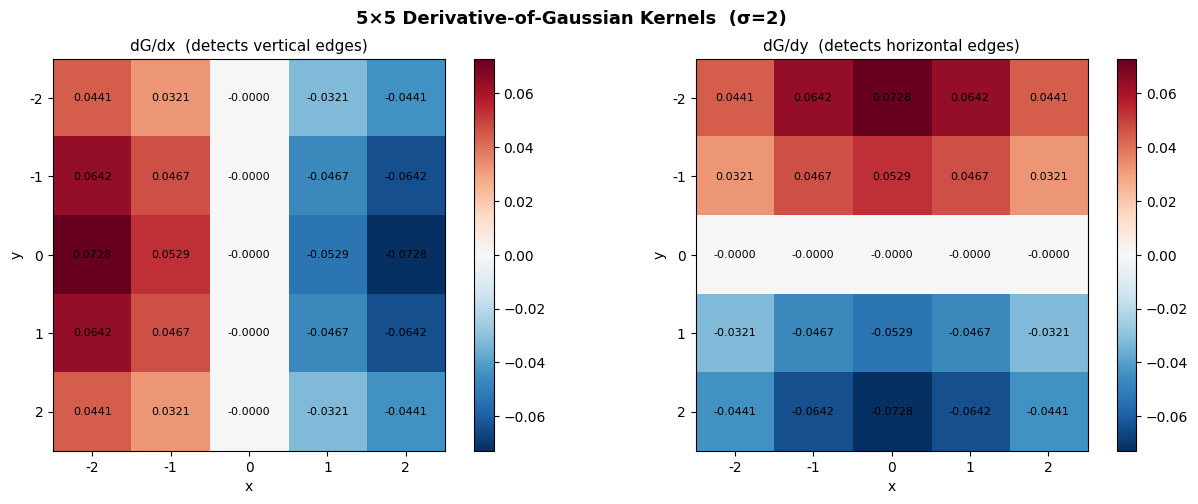

In [22]:
# Visualize both 5x5 DoG kernels as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('5×5 Derivative-of-Gaussian Kernels  (σ=2)', fontsize=13, fontweight='bold')

for ax, kernel, title in zip(axes,
                              [kernel_dx, kernel_dy],
                              ['dG/dx  (detects vertical edges)',
                               'dG/dy  (detects horizontal edges)']):
    im = ax.imshow(kernel, cmap='RdBu_r', interpolation='nearest',
                   vmin=-kernel_dx.max(), vmax=kernel_dx.max())
    plt.colorbar(im, ax=ax)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{kernel[i,j]:.4f}', ha='center', va='center',
                    fontsize=8, color='black')
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(5)); ax.set_xticklabels(['-2','-1','0','1','2'])
    ax.set_yticks(range(5)); ax.set_yticklabels(['-2','-1','0','1','2'])
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.savefig('../outputs/q6/q6_dog_kernels_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## (c) 51×51 DoG Kernel — 3D Surface Plot (x-direction)

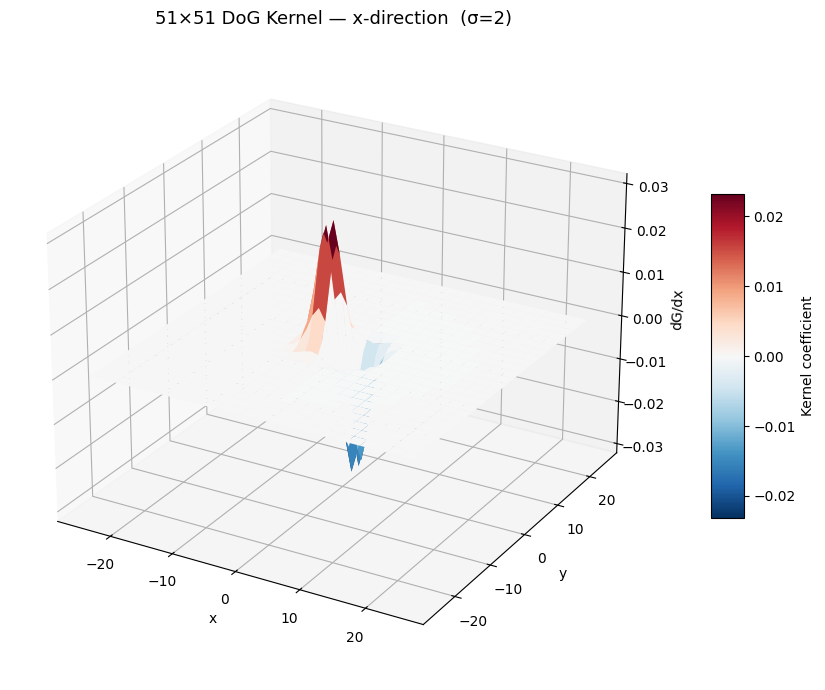

In [23]:
# Compute 51x51 DoG kernel (x-direction)
kernel_dx_51, _ = dog_kernels(size=51, sigma=sigma)

ax_c      = np.arange(-25, 26)
X51, Y51  = np.meshgrid(ax_c, ax_c)

fig = plt.figure(figsize=(11, 7))
ax3d = fig.add_subplot(111, projection='3d')

surf = ax3d.plot_surface(X51, Y51, kernel_dx_51,
                          cmap=cm.RdBu_r,
                          linewidth=0,
                          antialiased=True)

fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10, label='Kernel coefficient')
ax3d.set_title(f'51×51 DoG Kernel — x-direction  (σ={sigma})', fontsize=13)
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('dG/dx')
ax3d.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig('../outputs/q6/q6_dog_kernel_51x51_3d.png', dpi=150, bbox_inches='tight')
plt.show()


## (d) Image Gradients Using DoG Kernels

In [24]:
# Apply DoG kernels using cv.filter2D
# Use CV_32F depth to preserve signed gradient values (negative and positive)
img_float = img.astype(np.float32)

grad_x_dog = cv.filter2D(img_float, cv.CV_32F, kernel_dx.astype(np.float32))
grad_y_dog = cv.filter2D(img_float, cv.CV_32F, kernel_dy.astype(np.float32))

# Gradient magnitude
grad_mag_dog = np.sqrt(grad_x_dog**2 + grad_y_dog**2)

# Normalize all to [0, 255] for display
grad_x_disp   = cv.normalize(grad_x_dog,   None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
grad_y_disp   = cv.normalize(grad_y_dog,   None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
grad_mag_disp = cv.normalize(grad_mag_dog, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

print("DoG gradient results:")
print(f"  grad_x  — min={grad_x_dog.min():.3f}, max={grad_x_dog.max():.3f}")
print(f"  grad_y  — min={grad_y_dog.min():.3f}, max={grad_y_dog.max():.3f}")
print(f"  magnitude — min={grad_mag_dog.min():.3f}, max={grad_mag_dog.max():.3f}")


DoG gradient results:
  grad_x  — min=-104.543, max=108.727
  grad_y  — min=-91.810, max=100.662
  magnitude — min=0.000, max=108.727


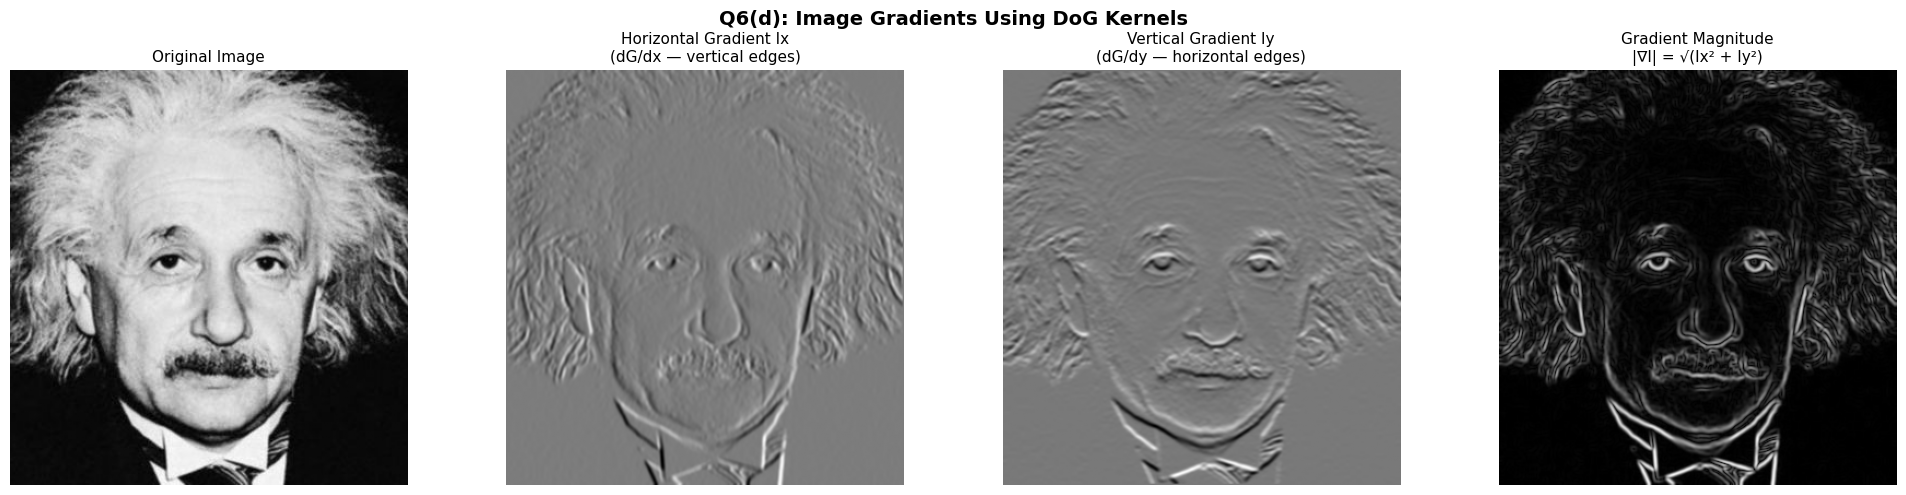

In [25]:
# Plot DoG gradient results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Q6(d): Image Gradients Using DoG Kernels', fontsize=14, fontweight='bold')

axes[0].imshow(img,           cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=11); axes[0].axis('off')

axes[1].imshow(grad_x_disp,   cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Horizontal Gradient Ix\n(dG/dx — vertical edges)', fontsize=11)
axes[1].axis('off')

axes[2].imshow(grad_y_disp,   cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Vertical Gradient Iy\n(dG/dy — horizontal edges)', fontsize=11)
axes[2].axis('off')

axes[3].imshow(grad_mag_disp, cmap='gray', vmin=0, vmax=255)
axes[3].set_title('Gradient Magnitude\n|∇I| = √(Ix² + Iy²)', fontsize=11)
axes[3].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q6/q6_dog_gradients.png', dpi=150, bbox_inches='tight')
plt.show()


## (e) Comparison with `cv.Sobel()`


In [26]:
# Compute Sobel gradients
grad_x_sobel = cv.Sobel(img, cv.CV_32F, dx=1, dy=0, ksize=3)
grad_y_sobel = cv.Sobel(img, cv.CV_32F, dx=0, dy=1, ksize=3)
grad_mag_sobel = np.sqrt(grad_x_sobel**2 + grad_y_sobel**2)

# Normalize for display
gx_s_disp  = cv.normalize(grad_x_sobel,   None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
gy_s_disp  = cv.normalize(grad_y_sobel,   None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
gm_s_disp  = cv.normalize(grad_mag_sobel, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

print("Sobel gradient results:")
print(f"  grad_x  — min={grad_x_sobel.min():.1f}, max={grad_x_sobel.max():.1f}")
print(f"  grad_y  — min={grad_y_sobel.min():.1f}, max={grad_y_sobel.max():.1f}")
print(f"  magnitude — min={grad_mag_sobel.min():.1f}, max={grad_mag_sobel.max():.1f}")


Sobel gradient results:
  grad_x  — min=-752.0, max=727.0
  grad_y  — min=-708.0, max=630.0
  magnitude — min=0.0, max=756.6


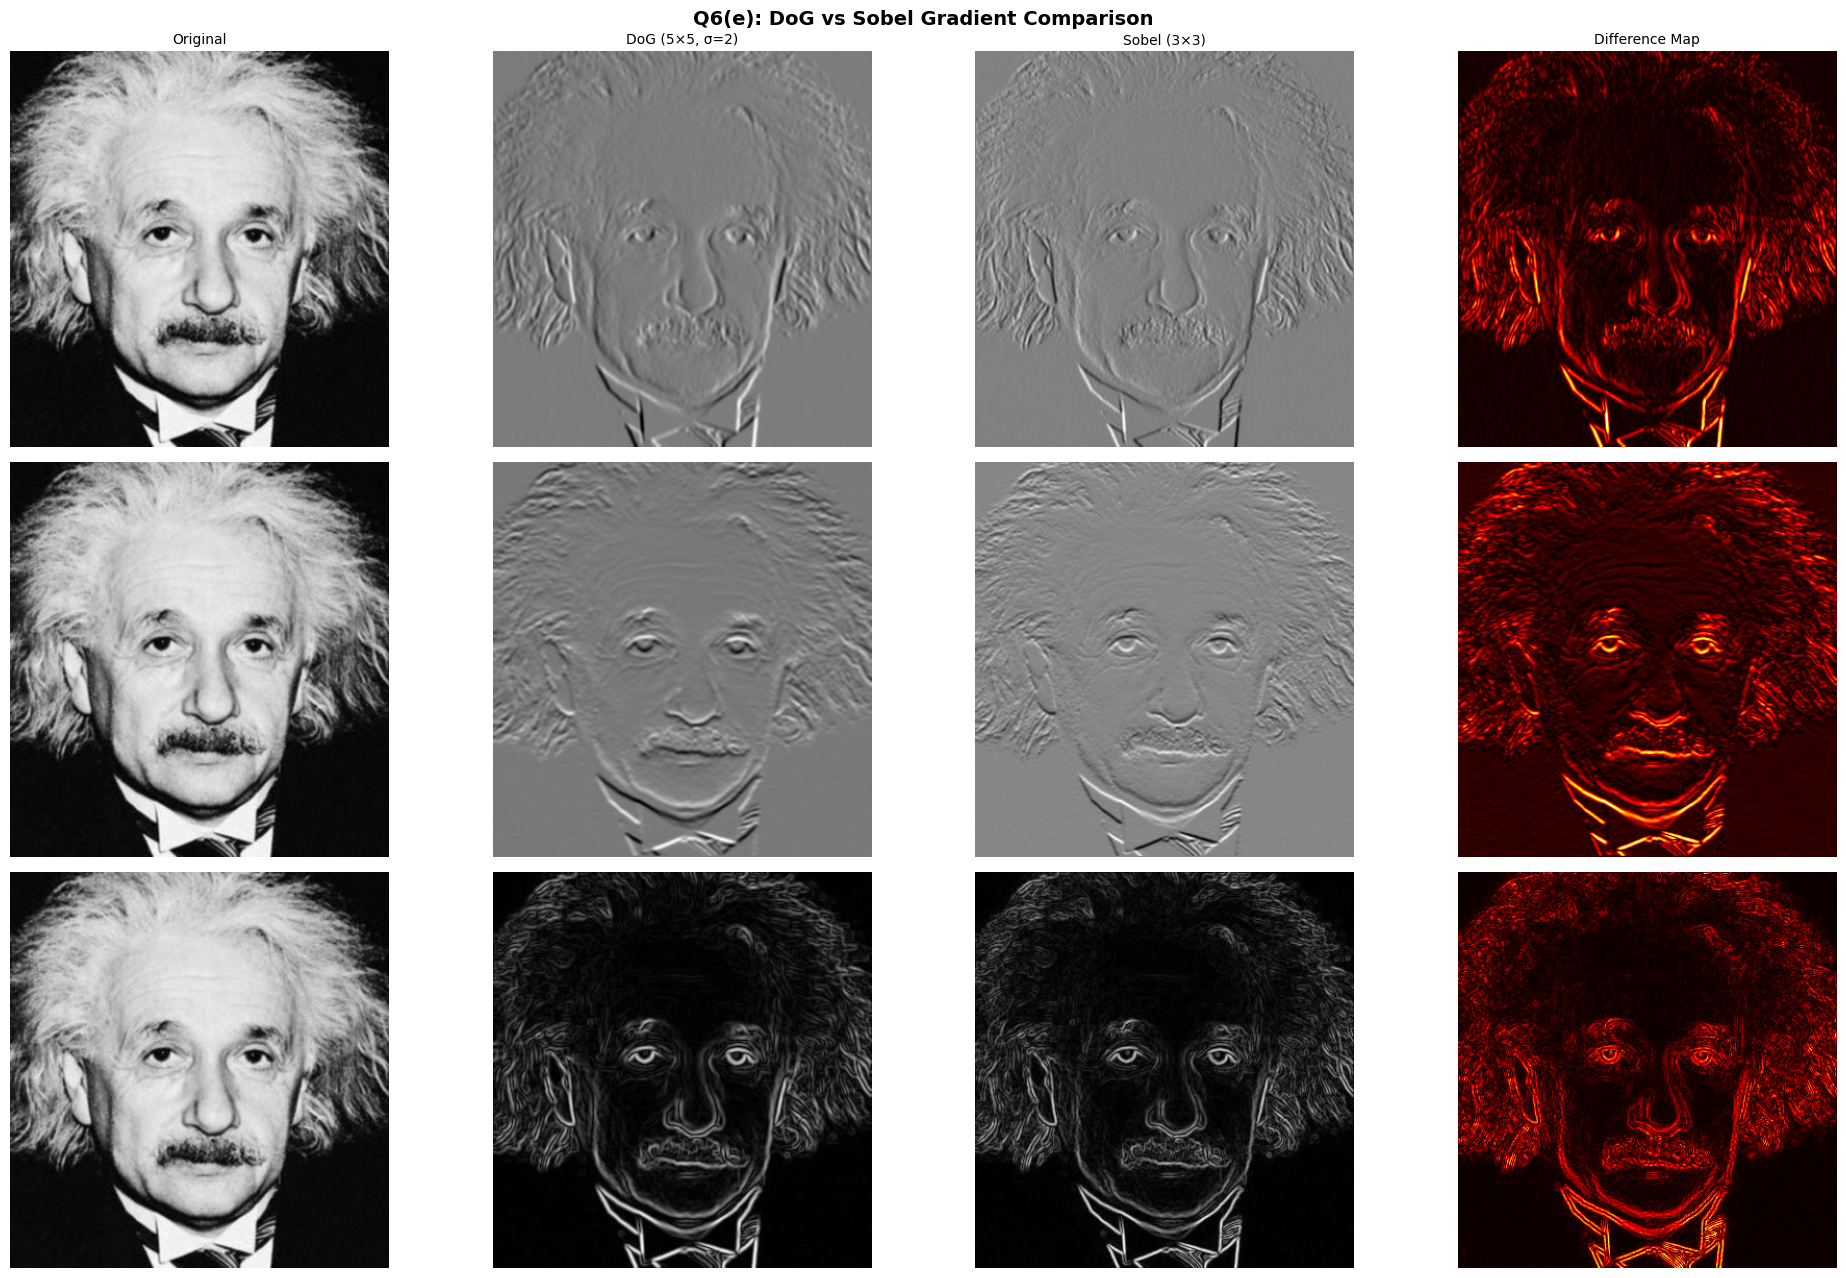

In [27]:
# Side-by-side: DoG vs Sobel
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle('Q6(e): DoG vs Sobel Gradient Comparison', fontsize=14, fontweight='bold')

row_labels = ['Horizontal Gradient Ix', 'Vertical Gradient Iy', 'Gradient Magnitude |∇I|']
dog_imgs   = [grad_x_disp,  grad_y_disp,  grad_mag_disp]
sobel_imgs = [gx_s_disp,    gy_s_disp,    gm_s_disp]

for row in range(3):
    # Original
    axes[row, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title('Original' if row == 0 else '', fontsize=10)
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(row_labels[row], fontsize=10)

    # DoG
    axes[row, 1].imshow(dog_imgs[row], cmap='gray', vmin=0, vmax=255)
    axes[row, 1].set_title('DoG (5×5, σ=2)' if row == 0 else '', fontsize=10)
    axes[row, 1].axis('off')

    # Sobel
    axes[row, 2].imshow(sobel_imgs[row], cmap='gray', vmin=0, vmax=255)
    axes[row, 2].set_title('Sobel (3×3)' if row == 0 else '', fontsize=10)
    axes[row, 2].axis('off')

    # Difference
    diff_img = cv.absdiff(dog_imgs[row], sobel_imgs[row])
    axes[row, 3].imshow(diff_img, cmap='hot')
    axes[row, 3].set_title('Difference Map' if row == 0 else '', fontsize=10)
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q6/q6_dog_vs_sobel.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# Quantitative comparison
print(f"{'Metric':<35} {'DoG (5x5)':>12} {'Sobel (3x3)':>12}")
print("-" * 62)

for label, d, s in [
    ('Grad X  — max response',     grad_x_dog.max(),   grad_x_sobel.max()),
    ('Grad X  — min response',     grad_x_dog.min(),   grad_x_sobel.min()),
    ('Grad Mag — max',             grad_mag_dog.max(), grad_mag_sobel.max()),
    ('Grad Mag — mean',            grad_mag_dog.mean(),grad_mag_sobel.mean()),
]:
    print(f"{label:<35} {d:>12.3f} {s:>12.3f}")

# Pixel-wise difference in displayed magnitude maps
diff_mag = cv.absdiff(grad_mag_disp, gm_s_disp)
print()
print(f"Magnitude display difference — max: {diff_mag.max()}, mean: {diff_mag.mean():.2f}")


Metric                                 DoG (5x5)  Sobel (3x3)
--------------------------------------------------------------
Grad X  — max response                   108.727      727.000
Grad X  — min response                  -104.543     -752.000
Grad Mag — max                           108.727      756.637
Grad Mag — mean                           10.195       67.505

Magnitude display difference — max: 87, mean: 5.96
